# Detecting Deforestation in the Netherlands

**Names**: Anthony Kamau

**Course**: Spatial Statistics and Machine Learning (INFOMSSML)

**Supervisor**: Dr. Menno Straatsma

## 1) Loading All Packages and Data

In [42]:
# Import packages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
from shapely.geometry import box, mapping
import pystac_client
import planetary_computer
import stackstac
import rich.table
import dask.diagnostics

import os
from os.path import join as pjoin
os.environ['USE_PYGEOS'] = '0'

# Output directories
scratch_dir = './scratch'
os.makedirs(scratch_dir, exist_ok=True)

In [ ]:
# [1]
# Load in the four forest areas of interest (AOI)
forests = gpd.read_file('Forests/Forests.shp') # CRS: EPSGH: 28992 (RD New)

# Add the metadata columns
forest_metadata = {
    'Soesterduin':    {'province': 'Utrecht',    'density_type': 'sparse'},
    'Amerongse Bos':  {'province': 'Utrecht',    'density_type': 'dense'},
    'Speulderbos':    {'province': 'Gelderland', 'density_type': 'dense'},
    'Hoge Veluwe':    {'province': 'Gelderland', 'density_type': 'mixed'},
}

# Adding the metadata to the forest polygons
def get_province(forest_name):
    return forest_metadata[forest_name]['province']

def get_density(forest_name):
    return forest_metadata[forest_name]['density_type']

# Pass the functions into map()
forests['province'] = forests['Name'].map(get_province)
forests['density_type'] = forests['Name'].map(get_density)

print('Original CRS:', forests.crs)
print(forests[['Name', 'province', 'density_type']])

# Reproject to WGS84 for STAC bounding box query
forests_wgs84 = forests.to_crs(epsg=4326)

# Reproject to UTM 31N for raster analysis
epsg = 32631
forests_utm = forests.to_crs(epsg=epsg)

print(f'\nReprojected to EPSG:4326 and EPSG:{epsg}')

Original CRS: EPSG:28992
            Name    province density_type
0    Soesterduin     Utrecht       sparse
1  Amerongse Bos     Utrecht        dense
2    Speulderbos  Gelderland        dense
3    Hoge Veluwe  Gelderland        mixed

Reprojected to EPSG:4326 and EPSG:32631


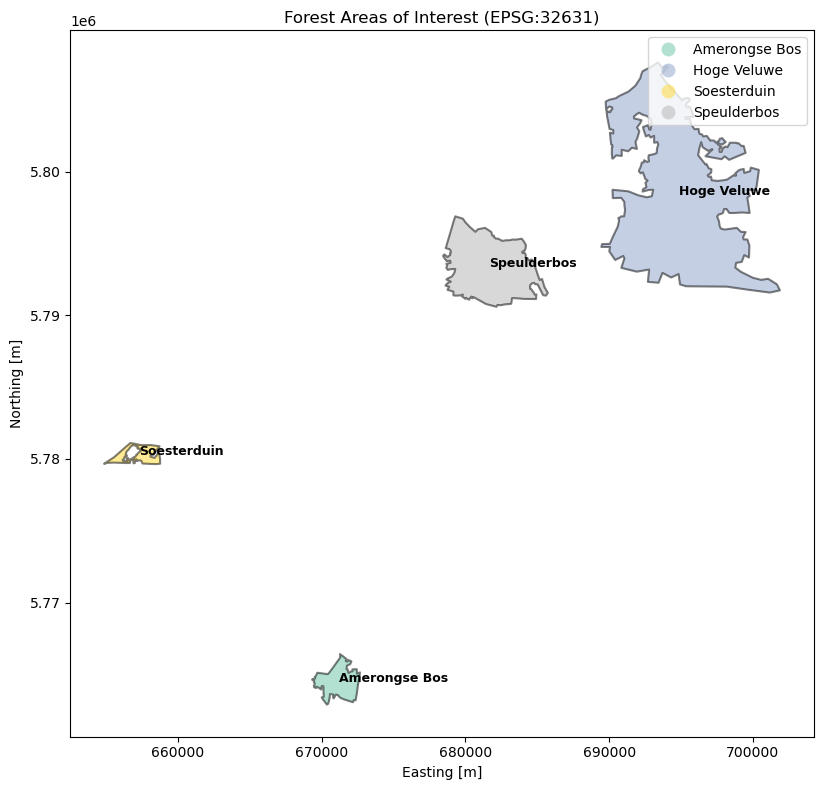

In [44]:
# [2]
# Visualise the forest AOIs
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

forests_utm.plot(ax=ax, column='Name', legend=True, alpha=0.5,
                 edgecolor='black', linewidth=1.5, cmap='Set2')
                 
for _, row in forests_utm.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['Name'], xy=(centroid.x, centroid.y),
                fontsize=9, fontweight='bold')

ax.set_title('Forest Areas of Interest (EPSG:32631)')
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(pjoin(scratch_dir, 'forest_aois.png'), dpi=150, bbox_inches='tight')

plt.show()

## 2) Connecting to the Planetary Computer STAC Catalog (Sentinel-2 L2A)

In [ ]:
# [3] [4]
# Compute combied bounding box in WGS84 with a small buffer
total_bounds = forests_wgs84.total_bounds
buffer = 0.02

bbox = [
    total_bounds[0] - buffer,  # x-min
    total_bounds[1] - buffer,  # y-min
    total_bounds[2] + buffer,  # x-max
    total_bounds[3] + buffer,  # y-max
]

# Creating a GeoJSON polygon for STAC search using the mapping function
aoi_geojson = mapping(box(bbox[0], bbox[1], bbox[2], bbox[3]))

print(f"Bounding box (lon/lat): {bbox}")

Bounding box (lon/lat): [5.243129035225959, 51.970636468313785, 5.976841940598579, 52.404379766287406]


In [21]:
# Connect to Planetary Computer STAC catalog
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)

daterange = {'interval': ['2016-01-01T00:00:00Z', '2025-12-31T23:59:59Z']}

# Searching for Sentinel-2 L2A items with CQL2 filter
search = catalog.search(
    filter_lang='cql2-json',
    filter={
        'op': 'and',
        'args': [
            {'op': 's_intersects', 'args': [{'property': 'geometry'}, aoi_geojson]},
            {'op': 'anyinteracts', 'args': [{'property': 'datetime'}, daterange]},
            {'op': '=', 'args': [{'property': 'collection'}, 'sentinel-2-l2a']},
            {'op': '<=', 'args': [{'property': 'eo:cloud_cover'}, 20]},
        ]
    },
    limit=1000,
)

items = list(search.items())
print(f'Found {len(items)} Sentinel-2 L2A scenes with <=20% cloud cover.')

Found 1067 Sentinel-2 L2A scenes with <=20% cloud cover.


In [40]:
# Description of the assets in the item
first_item = next(search.get_items())
planetary_computer.sign_item(first_item).assets
table = rich.table.Table("Asset Key", "Description")
for asset_key, asset in first_item.assets.items():
    table.add_row(asset_key, asset.title)
table

# The table shows not all bands have the same resolution

c:\Users\menno\anaconda3\envs\geospatial_pandas23\Lib\site-packages\pystac_client\item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Asset Key          ┃ Description                           ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ AOT                │ Aerosol optical thickness (AOT)       │
│ B01                │ Band 1 - Coastal aerosol - 60m        │
│ B02                │ Band 2 - Blue - 10m                   │
│ B03                │ Band 3 - Green - 10m                  │
│ B04                │ Band 4 - Red - 10m                    │
│ B05                │ Band 5 - Vegetation red edge 1 - 20m  │
│ B06                │ Band 6 - Vegetation red edge 2 - 20m  │
│ B07                │ Band 7 - Vegetation red edge 3 - 20m  │
│ B08                │ Band 8 - NIR - 10m                    │
│ B09                │ Band 9 - Water vapor - 60m            │
│ B11                │ Band 11 - SWIR (1.6) - 20m            │
│ B12                │ Band 12 - SWIR (2.2) - 20m            │
│ B8A                │ Band 8A - Vegetation red edge 4 - 20m │
│ SCL                │ Scene classfication map (SCL)         │
│ WVP                │ Water vapour (WVP)                    │
│ visual             │ True color image                      │
│ safe-manifest      │ SAFE manifest                         │
│ granule-metadata   │ Granule metadata                      │
│ inspire-metadata   │ INSPIRE metadata                      │
│ product-metadata   │ Product metadata                      │
│ datastrip-metadata │ Datastrip metadata                    │
│ tilejson           │ TileJSON with default rendering       │
│ rendered_preview   │ Rendered preview                      │
└────────────────────┴───────────────────────────────────────┘

## 3) Stack Sentinel-2 Imagery Into an xarray DataArray

In [23]:
# Specifying the resolution because not all sentinel-2 bands have the same resolution
resolution = 10 # in metres

stack = stackstac.stack(
    items,
    assets=['B04', 'B08', 'SCL'], # Red, NIR, and Scene Classification map
    epsg=epsg,
    resolution=resolution,
    bounds_latlon=bbox,
)

stack

<xarray.DataArray 'stackstac-97432202242ca2182098f2b1517fb562' (time: 1067,
                                                                band: 3,
                                                                y: 5005, x: 5189)> Size: 665GB
dask.array<fetch_raster_window, shape=(1067, 3, 5005, 5189), dtype=float64, chunksize=(1, 1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/43)
  * time                                     (time) datetime64[ns] 9kB 2016-0...
    id                                       (time) <U54 230kB 'S2A_MSIL2A_20...
    s2:product_uri                           (time) <U65 277kB 'S2A_MSIL2A_20...
    platform                                 (time) <U11 47kB 'Sentinel-2A' ....
    s2:nodata_pixel_percentage               (time) float64 9kB 0.008693 ... ...
    s2:unclassified_percentage               (time) float64 9kB 42.91 ... 2.548
    ...                                       ...
    instruments                              <U3 12B 'msi'
    s2:product_type                          <U7 28B 'S2MSI2A'
    s2:datatake_type                         <U8 32B 'INS-NOBS'
    constellation                            <U10 40B 'Sentinel 2'
    s2:saturated_defective_pixel_percentage  float64 8B 0.0
    epsg                                     int32 4B 32631
Attributes:
    spec:        RasterSpec(epsg=32631, bounds=(652590, 5760140, 704480, 5810...
    crs:         epsg:32631
    transform:   | 10.00, 0.00, 652590.00|\n| 0.00,-10.00, 5810190.00|\n| 0.0...
    resolution:  10

## 4) Cloud Masking Using the SCL Band

In [ ]:
# [5]
def validate_scl(scl):
    '''
    Create a boolean mask based on the labels we consider
    (clouds high probability, cloud shadows, no data, etc.)
    
    SCL classes retained:
        2: Dark area pixels
        4: Vegetation
        5: Not-vegetated
        6: Water
        7: Unclassified
    '''
    masked_labels = [0, 1, 3, 8, 9, 10, 11]
    keep = ~scl.isin(masked_labels)
    return keep


# Extract SCL band and create mask
scl = stack.sel(band='SCL')
cloud_mask = validate_scl(scl)

scl
# Shape is the same as the stack (minus the bands because we are only looking at one band here)

<xarray.DataArray 'stackstac-97432202242ca2182098f2b1517fb562' (time: 1067,
                                                                y: 5005, x: 5189)> Size: 222GB
dask.array<getitem, shape=(1067, 5005, 5189), dtype=float64, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/43)
  * time                                     (time) datetime64[ns] 9kB 2016-0...
    id                                       (time) <U54 230kB 'S2A_MSIL2A_20...
    s2:product_uri                           (time) <U65 277kB 'S2A_MSIL2A_20...
    platform                                 (time) <U11 47kB 'Sentinel-2A' ....
    s2:nodata_pixel_percentage               (time) float64 9kB 0.008693 ... ...
    s2:unclassified_percentage               (time) float64 9kB 42.91 ... 2.548
    ...                                       ...
    gsd                                      float64 8B 20.0
    title                                    <U29 116B 'Scene classfication m...
    common_name                              object 8B None
    center_wavelength                        object 8B None
    full_width_half_max                      object 8B None
    epsg                                     int32 4B 32631
Attributes:
    spec:        RasterSpec(epsg=32631, bounds=(652590, 5760140, 704480, 5810...
    crs:         epsg:32631
    transform:   | 10.00, 0.00, 652590.00|\n| 0.00,-10.00, 5810190.00|\n| 0.0...
    resolution:  10

## 5) Computing the NDVI

In [ ]:
# [6]
# NDVI = (NIR - Red) / (NIR + RED)
red = stack.sel(band='B04').astype('float32')
nir = stack.sel(band='B08').astype('float32')

ndvi = (nir - red) / (nir + red)

# Apply cloud mask
ndvi_masked = ndvi.where(cloud_mask)

# Set CRS for rioxarray
ndvi_masked = ndvi_masked.rio.write_crs(epsg, inplace=False)

ndvi_masked

<xarray.DataArray 'stackstac-97432202242ca2182098f2b1517fb562' (time: 1067,
                                                                y: 5005, x: 5189)> Size: 111GB
dask.array<where, shape=(1067, 5005, 5189), dtype=float32, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/43)
  * time                                     (time) datetime64[ns] 9kB 2016-0...
    id                                       (time) <U54 230kB 'S2A_MSIL2A_20...
    s2:product_uri                           (time) <U65 277kB 'S2A_MSIL2A_20...
    platform                                 (time) <U11 47kB 'Sentinel-2A' ....
    s2:nodata_pixel_percentage               (time) float64 9kB 0.008693 ... ...
    s2:unclassified_percentage               (time) float64 9kB 42.91 ... 2.548
    ...                                       ...
    band                                     <U3 12B 'SCL'
    title                                    <U29 116B 'Scene classfication m...
    common_name                              object 8B None
    center_wavelength                        object 8B None
    full_width_half_max                      object 8B None
    spatial_ref                              int32 4B 0
Attributes:
    spec:        RasterSpec(epsg=32631, bounds=(652590, 5760140, 704480, 5810...
    transform:   | 10.00, 0.00, 652590.00|\n| 0.00,-10.00, 5810190.00|\n| 0.0...
    resolution:  10

## 6) Clip NDVI to Forest AOIs

In [ ]:
# [7]
def clip_ndvi_to_forest(ndvi_da, forest_geom, target_epsg):
    """
    Clip an NDVI DataArray (ndvi_da) to a single forest polygon.
    
    1. Create a single geometry for each area:
    Use square brackets to make a list of a single geometry for each area

    Steps:
    1. Convert the Shapely geometry to a GeoJSON-like dict using `mapping()`
    2. Use square brackets to turn the geometry into a list of geometries for `rio.clip()`
    2. Clip the raster to the polygon
    """

    geom = [mapping(forest_geom)]
    clipped = ndvi_da.rio.clip(geom, crs=target_epsg, drop=True)
    return clipped

# Clip the NDVI for each forest indvidually
f1 = forests_utm.iloc[0]
f2 = forests_utm.iloc[1]
f3 = forests_utm.iloc[2]
f4 = forests_utm.iloc[3]

ndvi_f1 = clip_ndvi_to_forest(ndvi_masked, f1.geometry, epsg)
ndvi_f2 = clip_ndvi_to_forest(ndvi_masked, f2.geometry, epsg)
ndvi_f3 = clip_ndvi_to_forest(ndvi_masked, f3.geometry, epsg)
ndvi_f4 = clip_ndvi_to_forest(ndvi_masked, f4.geometry, epsg)

# Creating the dictionary with the appropriate forest names
ndvi_forests = {
    row['Name']: clip_ndvi_to_forest(ndvi_masked, row.geometry, epsg)
    for index, row in forests_utm.iterrows()
}

ndvi_forests

{'Soesterduin': <xarray.DataArray 'stackstac-97432202242ca2182098f2b1517fb562' (time: 1067,
                                                                 y: 146, x: 390)> Size: 243MB
 dask.array<getitem, shape=(1067, 146, 390), dtype=float32, chunksize=(1, 146, 390), chunktype=numpy.ndarray>
 Coordinates: (12/43)
   * time                                     (time) datetime64[ns] 9kB 2016-0...
     id                                       (time) <U54 230kB 'S2A_MSIL2A_20...
     s2:product_uri                           (time) <U65 277kB 'S2A_MSIL2A_20...
     platform                                 (time) <U11 47kB 'Sentinel-2A' ....
     s2:nodata_pixel_percentage               (time) float64 9kB 0.008693 ... ...
     s2:unclassified_percentage               (time) float64 9kB 42.91 ... 2.548
     ...                                       ...
     band                                     <U3 12B 'SCL'
     title                                    <U29 116B 'Scene classfication m..

## 7) Computing the Annual NDVI for the Growing Season

In [ ]:
# [8] [9] [10]
def annual_growing_season_median(ndvi_da):
    """
    Compute the annual median NDVI during the growing season (April-October).

    Steps:
    1) Computing the ndvi_da for per month
    2) Filter to growing season months (April (4) through October (10))
    3) Computing the annual median ('YS' = year start frequency)
    """

    months = ndvi_da.time.dt.month
    growing = ndvi_da.where((months >= 4) & (months <= 10), drop = True)
    annual = growing.resample(time = 'YS').median(dim = 'time', skipna = True)
    return annual

# Computing the annual composites (lazy Dask arrays)
annual_ndvi = {
    name: annual_growing_season_median(ndvi_da)
    for name, ndvi_da in ndvi_forests.items()
}

annual_ndvi

{'Soesterduin': <xarray.DataArray 'stackstac-97432202242ca2182098f2b1517fb562' (time: 10,
                                                                 y: 146, x: 390)> Size: 2MB
 dask.array<stack, shape=(10, 146, 390), dtype=float32, chunksize=(1, 146, 390), chunktype=numpy.ndarray>
 Coordinates: (12/16)
   * time                                     (time) datetime64[ns] 80B 2016-0...
   * y                                        (y) float64 1kB 5.781e+06 ... 5....
   * x                                        (x) float64 3kB 6.549e+05 ... 6....
     proj:code                                <U10 40B 'EPSG:32631'
     instruments                              <U3 12B 'msi'
     s2:product_type                          <U7 28B 'S2MSI2A'
     ...                                       ...
     band                                     <U3 12B 'SCL'
     title                                    <U29 116B 'Scene classfication m...
     common_name                              object 8B Non

In [29]:
# Download and process the actual data

computed_annual_ndvi = {}

for name, da in annual_ndvi.items():
    print(f"Computing {name}")
    with dask.diagnostics.ProgressBar():
        computed_annual_ndvi[name] = da.compute()

Computing Soesterduin
[#########                               ] | 22% Completed | 27.21 ss

c:\Users\menno\anaconda3\envs\geospatial_pandas23\Lib\site-packages\dask\_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


[################                        ] | 41% Completed | 47.68 s

c:\Users\menno\anaconda3\envs\geospatial_pandas23\Lib\site-packages\dask\_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


[########################################] | 100% Completed | 131.65 s
Computing Amerongse Bos
[########################################] | 100% Completed | 90.45 s
Computing Speulderbos
[########################################] | 100% Completed | 402.91 s
Computing Hoge Veluwe
[########################################] | 100% Completed | 12m 16s


## 8) NDVI Temporal Profiles

In [ ]:
# [11]
# Computing the spatial mean NDVI per forest per year
mean_1 = computed_annual_ndvi['Soesterduin'].mean(dim=['x', 'y'], skipna=True)
mean_2 = computed_annual_ndvi['Amerongse Bos'].mean(dim=['x', 'y'], skipna=True)
mean_3 = computed_annual_ndvi['Speulderbos'].mean(dim=['x', 'y'], skipna=True)
mean_4 = computed_annual_ndvi['Hoge Veluwe'].mean(dim=['x', 'y'], skipna=True)


records = []
for ts, val in mean_1.to_series().items():
    records.append({'year': pd.Timestamp(ts).year, 'forest': 'Soesterduin', 'province': 'Utrecht', 'mean_ndvi': float(val)})
for ts, val in mean_2.to_series().items():
    records.append({'year': pd.Timestamp(ts).year, 'forest': 'Amerongse Bos', 'province': 'Utrecht', 'mean_ndvi': float(val)})
for ts, val in mean_3.to_series().items():
    records.append({'year': pd.Timestamp(ts).year, 'forest': 'Speulderbos', 'province': 'Gelderland', 'mean_ndvi': float(val)})
for ts, val in mean_4.to_series().items():
    records.append({'year': pd.Timestamp(ts).year, 'forest': 'Hoge Veluwe', 'province': 'Gelderland', 'mean_ndvi': float(val)})

# Putting all of the records together in a dataframe
df_profiles = pd.DataFrame(records)
print(df_profiles)

    year         forest    province  mean_ndvi
0   2016    Soesterduin     Utrecht   0.753421
1   2017    Soesterduin     Utrecht   0.780629
2   2018    Soesterduin     Utrecht   0.780831
3   2019    Soesterduin     Utrecht   0.768370
4   2020    Soesterduin     Utrecht   0.771164
5   2021    Soesterduin     Utrecht   0.782678
6   2022    Soesterduin     Utrecht   0.476468
7   2023    Soesterduin     Utrecht   0.471625
8   2024    Soesterduin     Utrecht   0.459395
9   2025    Soesterduin     Utrecht   0.460141
10  2016  Amerongse Bos     Utrecht   0.806524
11  2017  Amerongse Bos     Utrecht   0.809382
12  2018  Amerongse Bos     Utrecht   0.802643
13  2019  Amerongse Bos     Utrecht   0.782622
14  2020  Amerongse Bos     Utrecht   0.794891
15  2021  Amerongse Bos     Utrecht   0.811425
16  2022  Amerongse Bos     Utrecht   0.500936
17  2023  Amerongse Bos     Utrecht   0.505274
18  2024  Amerongse Bos     Utrecht   0.490234
19  2025  Amerongse Bos     Utrecht   0.486261
20  2016    S

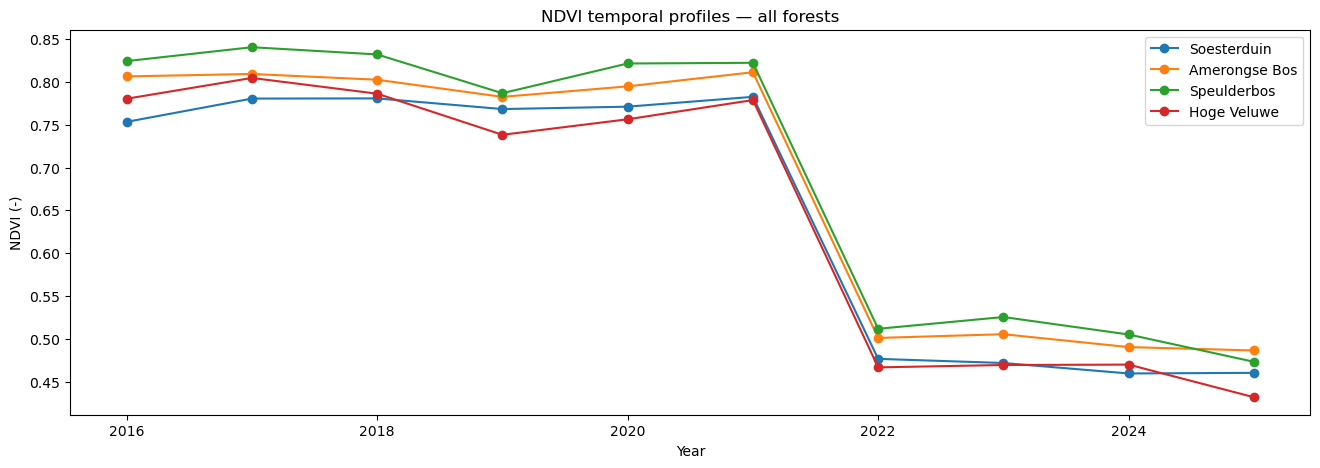

In [45]:
# [12]
# Plotting the temporal profiles
fig, ax = plt.subplots(1, 1, figsize=(16, 5))

for forest in df_profiles['forest'].unique():
    forest_data = df_profiles[df_profiles['forest'] == forest]
    ax.plot(forest_data['year'], forest_data['mean_ndvi'], marker='o', label=forest)

ax.set_ylabel('NDVI (-)')
ax.set_xlabel('Year')
ax.set_title('NDVI temporal profiles — all forests')
ax.legend()
plt.savefig(pjoin(scratch_dir, 'ndvi_temporal_profiles_all.png'), dpi = 150, bbox_inches = 'tight')
plt.show()

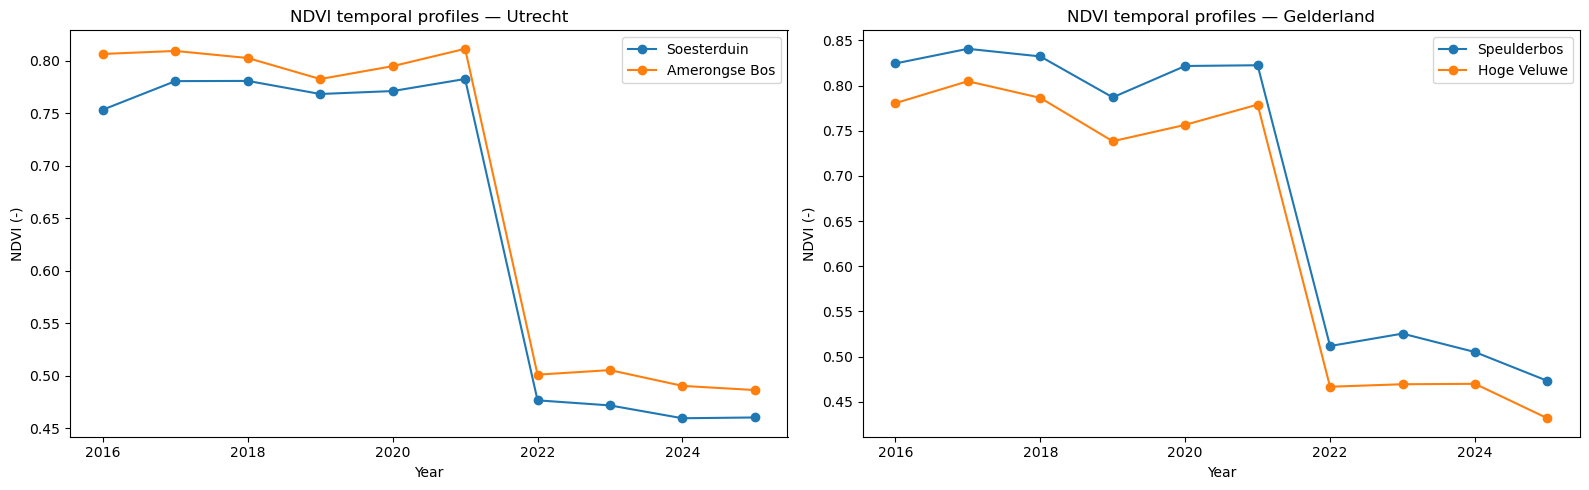

In [46]:
# Seperating the temporal profiles by province
fig, axes = plt.subplots(1, 2, figsize = (16, 5))

for ax, province in zip(axes, ['Utrecht','Gelderland']):
    sub = df_profiles[df_profiles['province'] == province]
    for forest in sub['forest'].unique():
        fdata = sub[sub['forest'] == forest]
        ax.plot(fdata['year'], fdata['mean_ndvi'], marker='o', label=forest)
    ax.set_ylabel('NDVI (-)')
    ax.set_xlabel('Year')
    ax.set_title(f'NDVI temporal profiles — {province}')
    ax.legend()

plt.tight_layout()
plt.savefig(pjoin(scratch_dir, 'ndvi_temporal_profiles_separate.png'), dpi=150, bbox_inches='tight')
plt.show() 

## 9) NDVI Difference Mapping

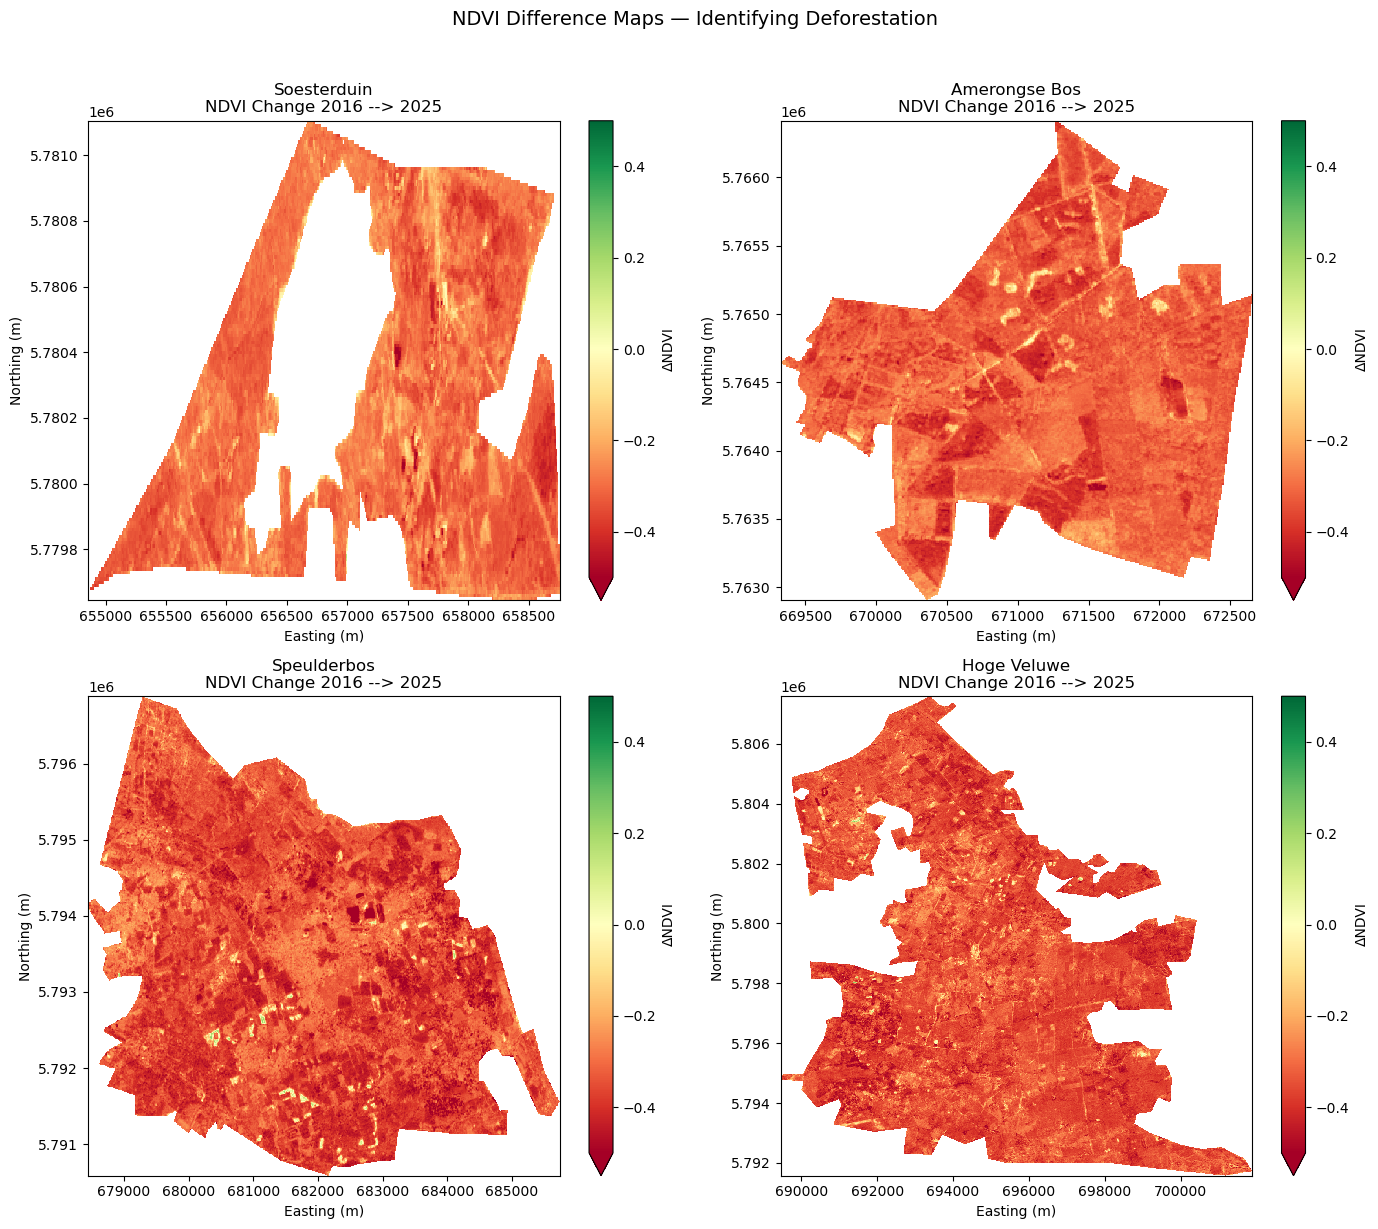

In [49]:
# [13] [14]
# Calculate the difference between in mean NDVI between two years, a reference year and a change year
ref_year = 2016
change_year = 2025

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, da) in zip(axes, computed_annual_ndvi.items()):
    nd_ref = da.sel(time = str(ref_year), method='nearest')
    nd_change = da.sel(time = str(change_year), method = 'nearest')
    nd_dif = nd_change - nd_ref
    nd_dif.plot(ax = ax, cmap = 'RdYlGn', vmin = -0.5, vmax = 0.5,
                add_colorbar = True, cbar_kwargs={'label': 'ΔNDVI'})
    ax.set_title(f'{name}\nNDVI Change {ref_year} --> {change_year}')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')

plt.suptitle('NDVI Difference Maps — Identifying Deforestation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(pjoin(scratch_dir, 'ndvi_difference_maps.png'), dpi=150, bbox_inches='tight')
plt.show()

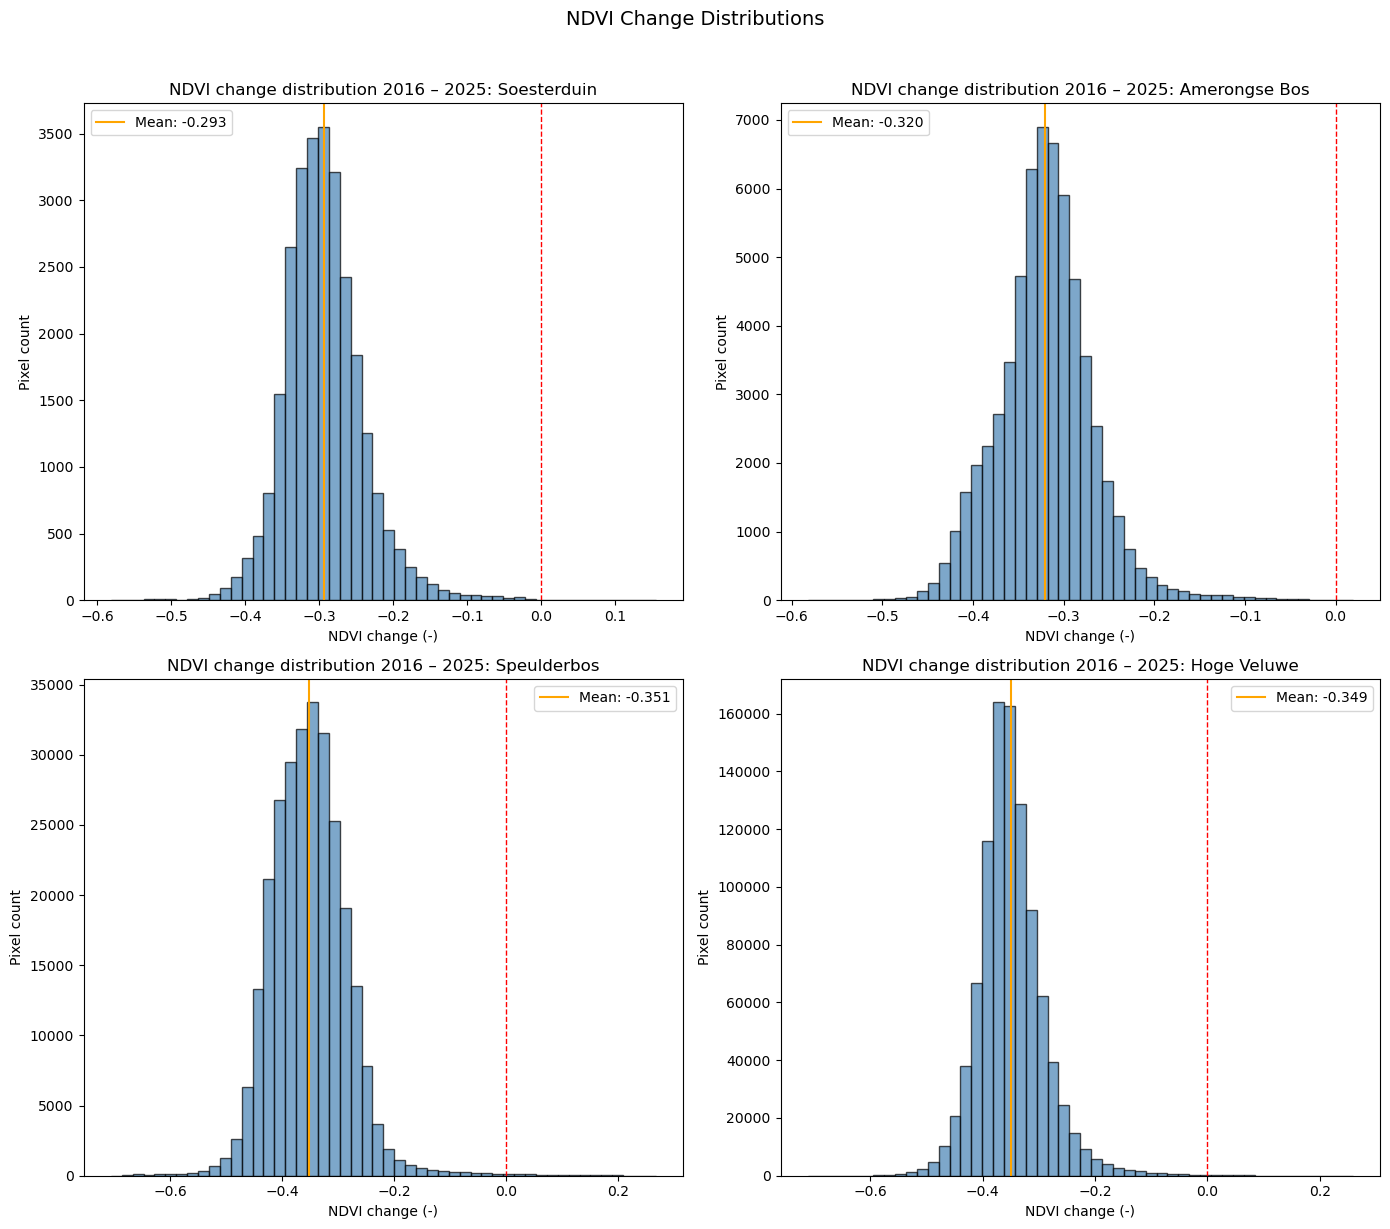

In [50]:
# [15]
# Histograms of NDVI difference values per forest
fig, axes = plt.subplots(2, 2, figsize = (14, 12))
axes = axes.flatten()

for ax, (name, da) in zip(axes, computed_annual_ndvi.items()):
    nd_ref = da.sel(time = str(ref_year), method = 'nearest')
    nd_change = da.sel(time = str(change_year), method = 'nearest')
    nd_dif = nd_change - nd_ref
    vals = nd_dif.values.flatten()
    vals = vals[np.isfinite(vals)]
    ax.hist(vals, bins = 50, color = 'steelblue', edgecolor = 'black', alpha = 0.7)
    ax.axvline(0, color = 'red', linestyle = '--', linewidth=1)
    ax.axvline(np.mean(vals), color = 'orange', linestyle = '-', linewidth = 1.5,
               label = f'Mean: {np.mean(vals):.3f}')
    ax.legend()
    ax.set_xlabel('NDVI change (-)')
    ax.set_ylabel('Pixel count')
    ax.set_title(f'NDVI change distribution {ref_year} – {change_year}: {name}')

plt.suptitle('NDVI Change Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(pjoin(scratch_dir, 'ndvi_change_histograms.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10) Year-by-Year NDVI Change

In [ ]:
# [16]
# Creating a dataframe for the year-by--year change
pivot = df_profiles.pivot(index='forest', columns='year', values='mean_ndvi')
yby_diff = pivot.diff(axis=1).dropna(axis = 1) # dropping the 2016 column (all NAs)
print(yby_diff)

year               2017      2018      2019      2020      2021      2022  \
forest                                                                      
Amerongse Bos  0.002858 -0.006739 -0.020021  0.012269  0.016534 -0.310489   
Hoge Veluwe    0.024282 -0.018396 -0.048028  0.018127  0.022456 -0.312360   
Soesterduin    0.027208  0.000201 -0.012461  0.002794  0.011514 -0.306210   
Speulderbos    0.016220 -0.008425 -0.045314  0.034720  0.000810 -0.310810   

year               2023      2024      2025  
forest                                       
Amerongse Bos  0.004337 -0.015039 -0.003974  
Hoge Veluwe    0.002765  0.000467 -0.038117  
Soesterduin   -0.004843 -0.012230  0.000746  
Speulderbos    0.013738 -0.020413 -0.031893  


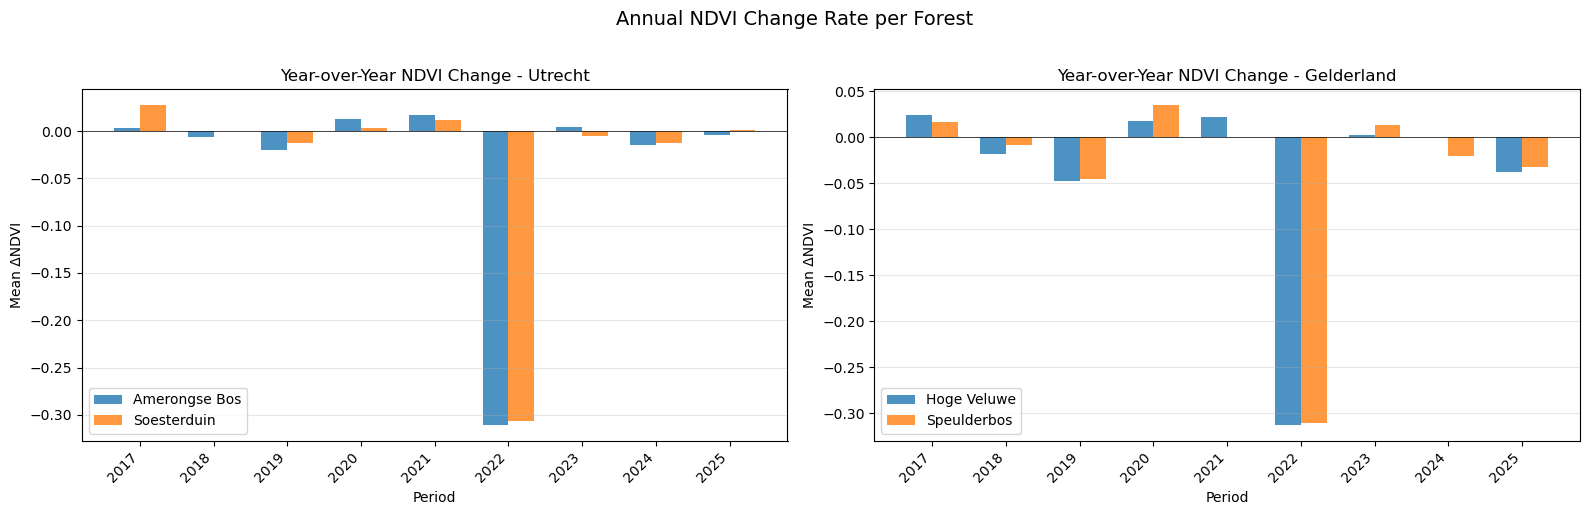

In [51]:
# [17]
# Plotting the year-by-year change
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, province in zip(axes, ['Utrecht', 'Gelderland']):
    province_forests = forests.loc[forests['province'] == province, 'Name'].values
    sub = yby_diff.loc[yby_diff.index.isin(province_forests)]
    x = np.arange(len(sub.columns))
    width = 0.35

    ax.bar(x, sub.iloc[0], width, label=sub.index[0], alpha=0.8)
    ax.bar(x + width, sub.iloc[1], width, label=sub.index[1], alpha=0.8)

    ax.set_title(f'Year-over-Year NDVI Change - {province}')
    ax.set_xlabel('Period')
    ax.set_ylabel('Mean ΔNDVI')
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(yby_diff.columns, rotation=45, ha='right')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Annual NDVI Change Rate per Forest', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(pjoin(scratch_dir, 'ndvi_yby_change.png'), dpi = 150, bbox_inches = 'tight')
plt.show()

## 11) Spatial NDVI Composites Per Year

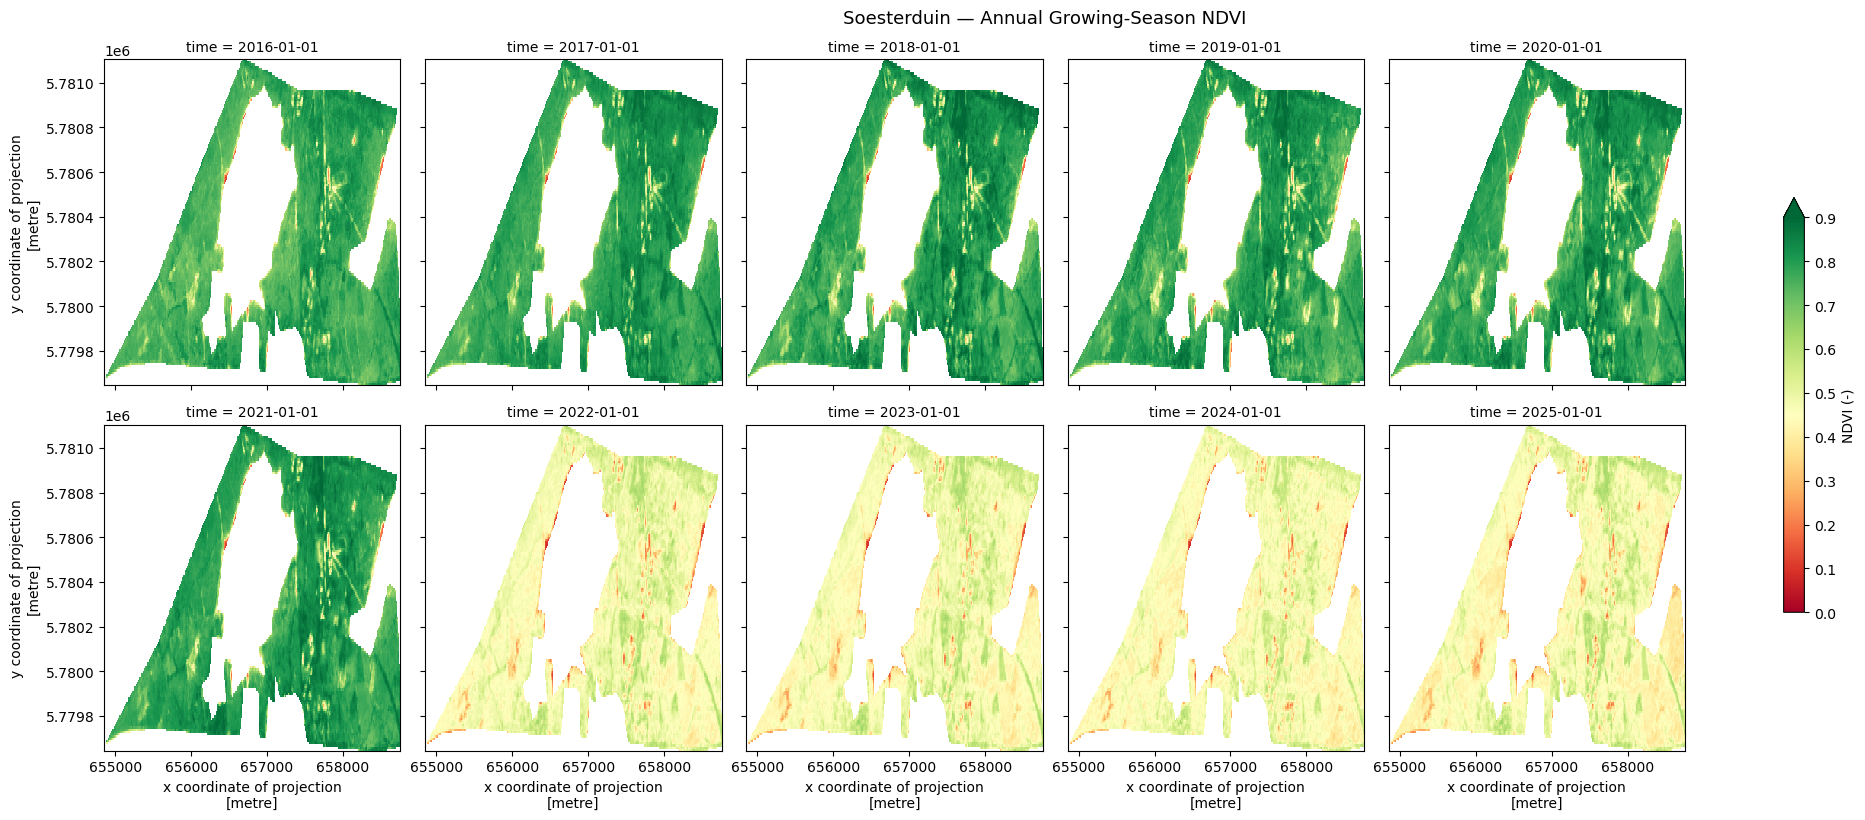

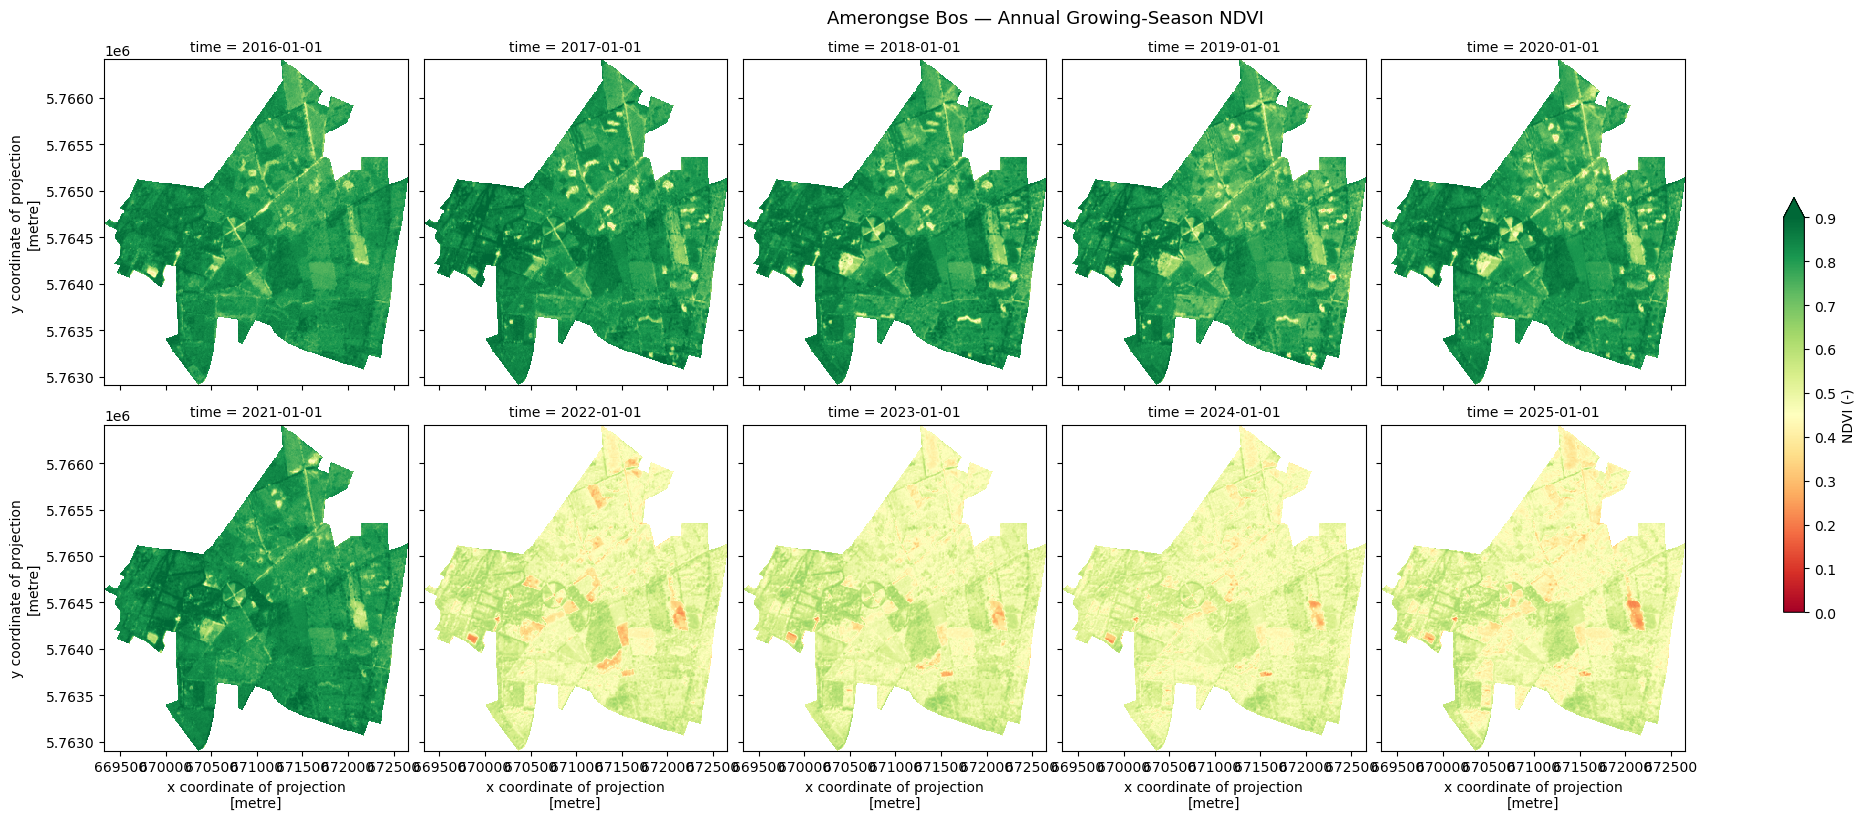

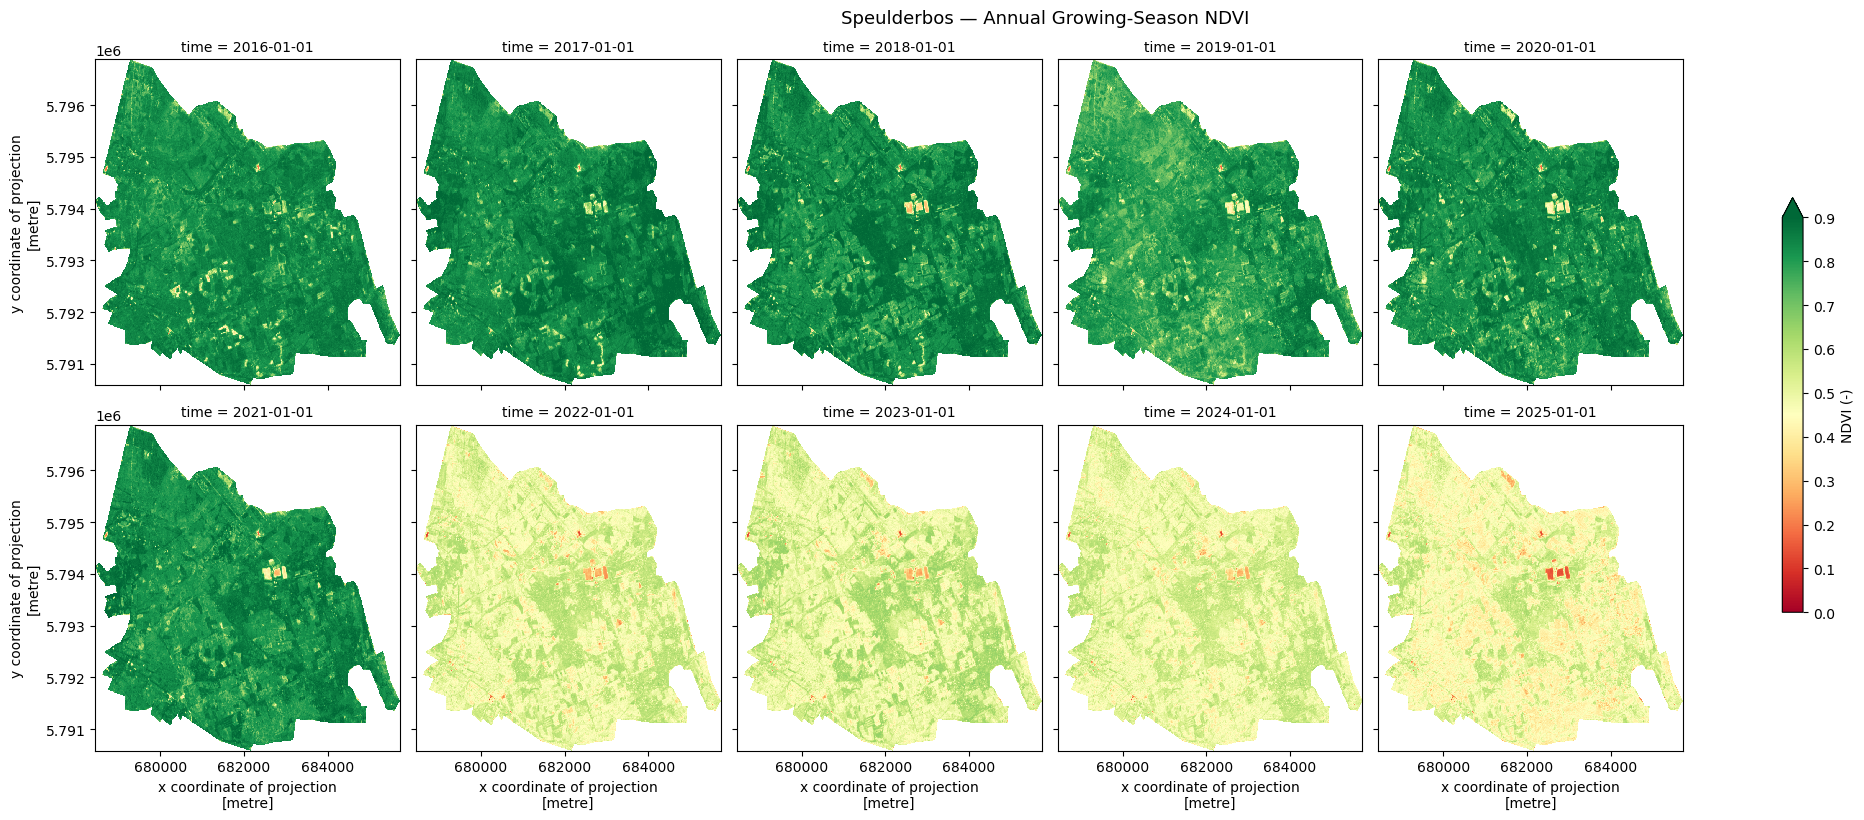

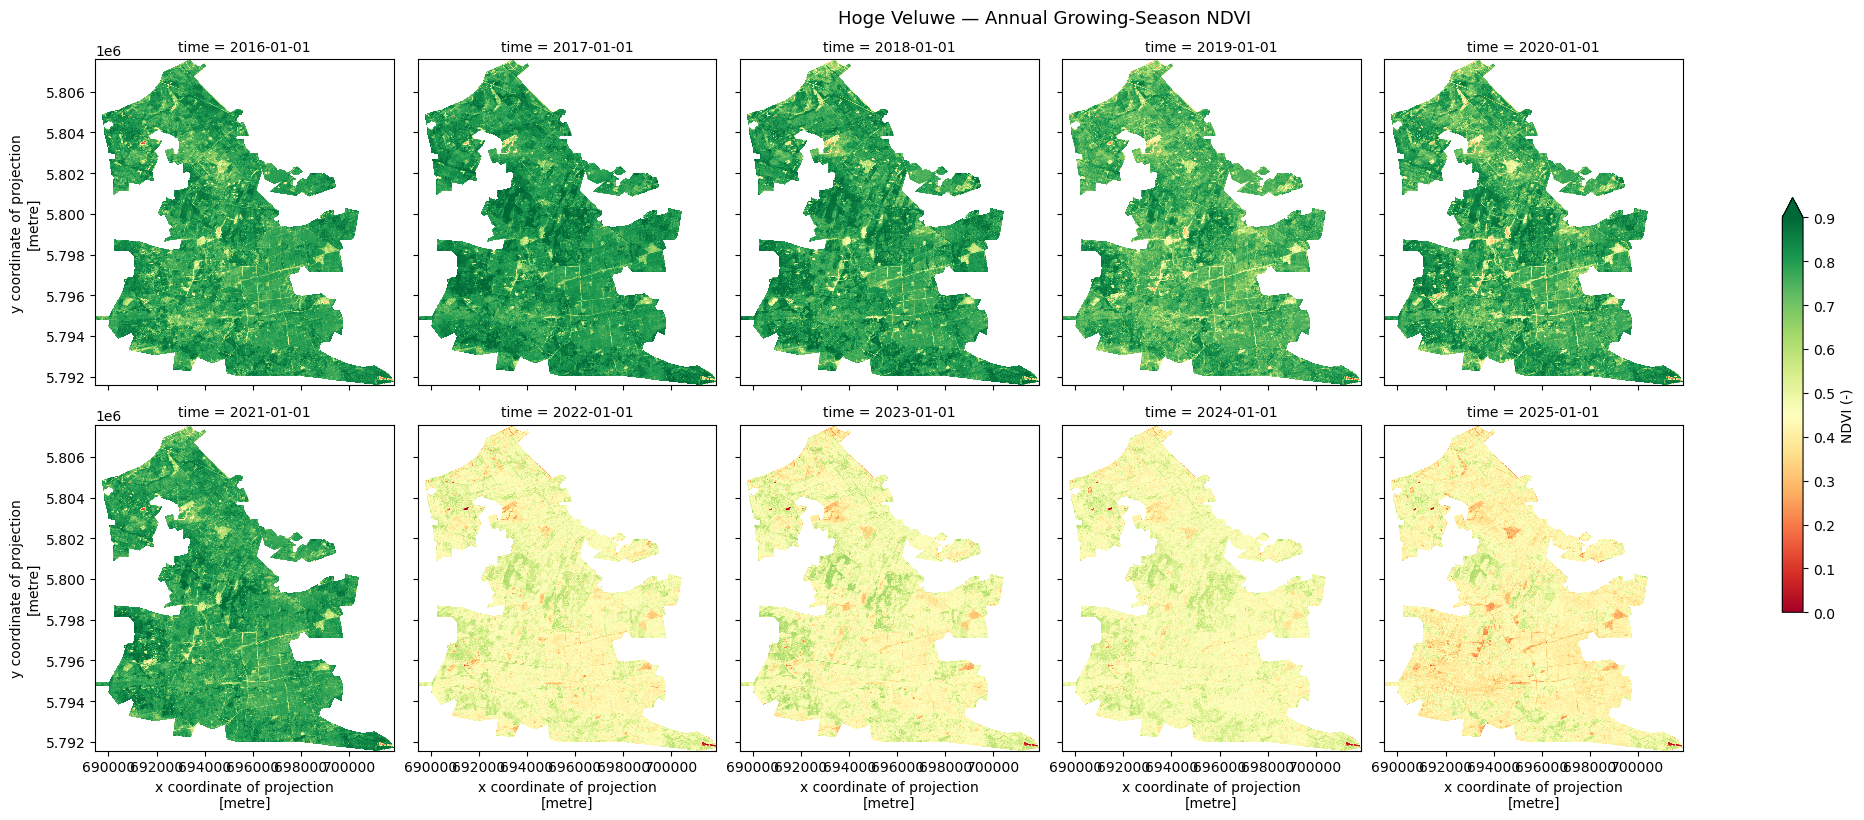

In [ ]:
# [18]
for name, da in computed_annual_ndvi.items():
    ndvi_plots = da.plot.imshow(
        col='time', col_wrap=5, size=4, aspect = 1,
        cmap='RdYlGn', vmin=0.0, vmax=0.9,
        cbar_kwargs={'label': 'NDVI (-)', 'shrink': 0.6}
    )

    plt.suptitle(f'{name} — Annual Growing-Season NDVI', fontsize=13, y=1.02)
    plt.savefig(pjoin(scratch_dir, f'ndvi_spatial_{name}.png'), dpi = 150, bbox_inches = 'tight')
    plt.show()

## 12) Export Annual Composites as GeoTiffs

In [ ]:
# [19] [20] [21]
# Save annual NDVI composites as multi-band GeoTIFFs
for name, da in computed_annual_ndvi.items():
    forest = name.lower().replace(' ', '_') # e.g. 'Amerongse Bos' --> 'amerongse_bos'
    out_path = pjoin(scratch_dir, f'ndvi_annual_{forest}.tif')
    
    da_export = da.copy()

    # Sets metadata that labels each band (name it 'long_name' because this name is recognised by QGIS)
    # otherwise, it will not open
    da_export.attrs['long_name'] = tuple(
        str(pd.Timestamp(t).year) for t in da_export.time.values
    )
    da_export.rio.write_crs(epsg, inplace=True)
    da_export.rio.set_spatial_dims(x_dim='x', y_dim='y', inplace=True)
    da_export.rio.to_raster(out_path, compress='LZW')
    print(f'Saved: {out_path}')

Saved: ./scratch\ndvi_annual_soesterduin.tif
Saved: ./scratch\ndvi_annual_amerongse_bos.tif
Saved: ./scratch\ndvi_annual_speulderbos.tif
Saved: ./scratch\ndvi_annual_hoge_veluwe.tif


## 13) Export Forest Polygons


In [43]:
# Export forest polygons as GeoPackage for QGIS
forests_utm.to_file(pjoin(scratch_dir, 'forests_utm.gpkg'), driver='GPKG')
forests_wgs84.to_file(pjoin(scratch_dir, 'forests_wgs84.geojson'), driver='GeoJSON')
print('Forest polygons exported.')

Forest polygons exported.


## 14) Summary Statistics

In [ ]:
#[22] [23]

summary = []
for name, da in computed_annual_ndvi.items():
    nd_ref = da.sel(time = str(ref_year), method = 'nearest')
    nd_change = da.sel(time = str(change_year), method = 'nearest')
    nd_dif = nd_change - nd_ref
    vals = nd_dif.values.flatten()
    vals = vals[np.isfinite(vals)]
    province = forests.loc[forests['Name'] == name, 'province'].values[0]
    summary.append({
        'Forest': name,
        'Province': province,
        'Mean ΔNDVI': f'{np.mean(vals):.3f}',
        'Median ΔNDVI': f'{np.median(vals):.3f}',
        'Std ΔNDVI': f'{np.std(vals):.3f}',
        'Min ΔNDVI': f'{np.min(vals):.3f}',
        'Max ΔNDVI': f'{np.max(vals):.3f}',
        'Pixels': len(vals),
    })

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

       Forest   Province Mean ΔNDVI Median ΔNDVI Std ΔNDVI Min ΔNDVI Max ΔNDVI  Pixels
  Soesterduin    Utrecht     -0.293       -0.297     0.053    -0.581     0.155   27710
Amerongse Bos    Utrecht     -0.320       -0.320     0.052    -0.582     0.019   60915
  Speulderbos Gelderland     -0.351       -0.354     0.069    -0.706     0.268  275949
  Hoge Veluwe Gelderland     -0.349       -0.354     0.059    -0.711     0.259  979276
